## 🚗 Vehicle Detection using YOLOv8

This section performs object detection on an input image using a pretrained **YOLOv8 model** from Ultralytics.

### 📌 Pipeline Overview
1. Load a pretrained YOLOv8 model (`yolov8m.pt`)
2. Read an input image from disk
3. Run inference to detect objects
4. Filter detections for vehicles (cars, trucks, buses)
5. Crop detected vehicles and save them locally
6. Visualize:
   - The original image with bounding boxes
   - The extracted vehicle crops

### ⚙️ Notes
- Only detections with labels **car**, **truck**, and **bus** are kept.
- Cropped images are saved in the `vehicle_crops/` directory.
- YOLO inference logging is disabled for cleaner output.

### 🎯 Output
- Annotated image with bounding boxes and confidence scores
- Grid visualization of detected vehicle crops


📸 Image: car.jpg | Vehicles: 2


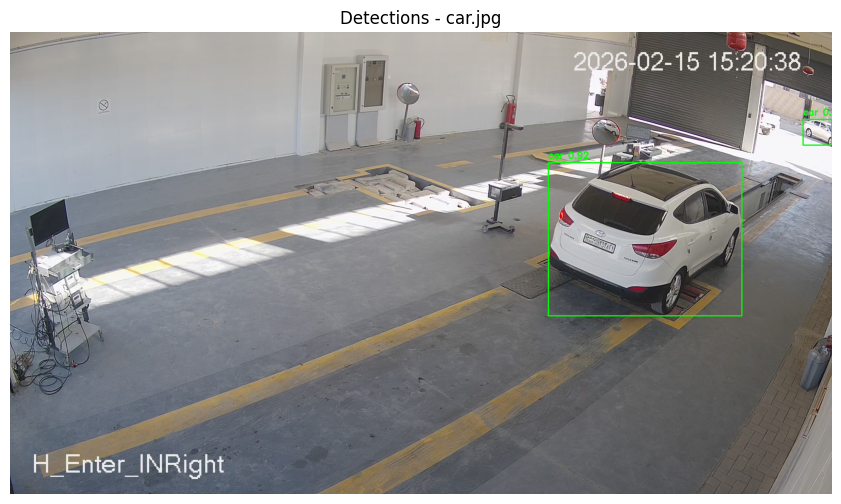

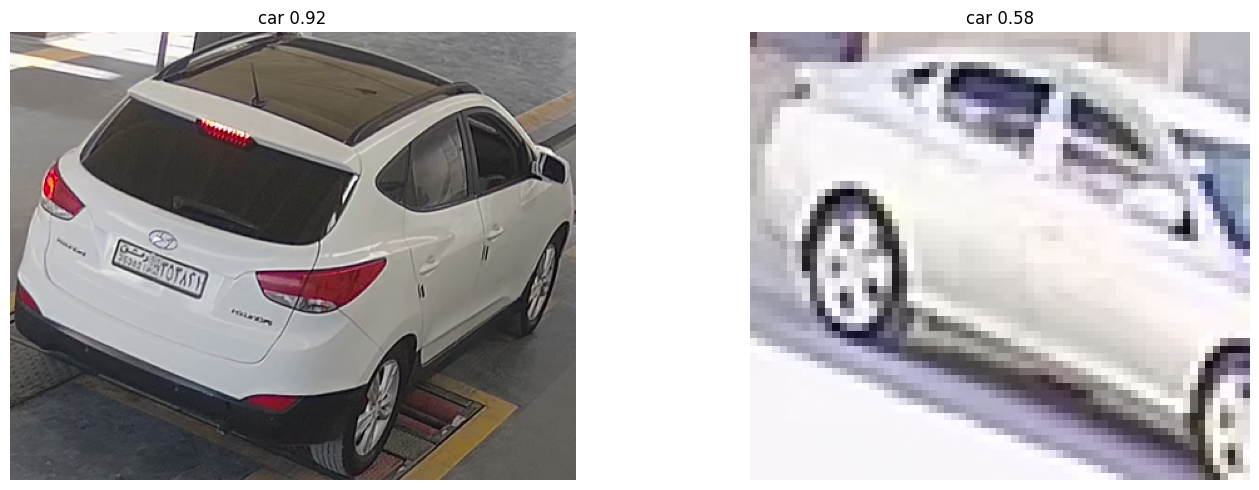


📸 Image: car2.jpg | Vehicles: 4


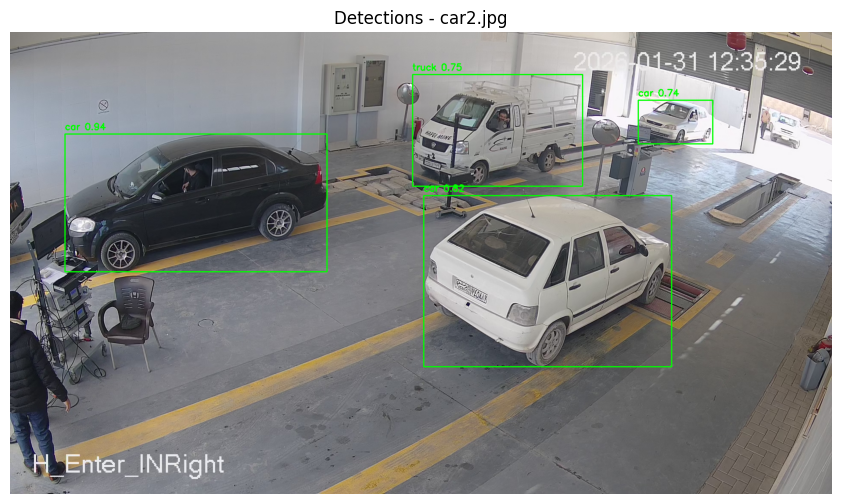

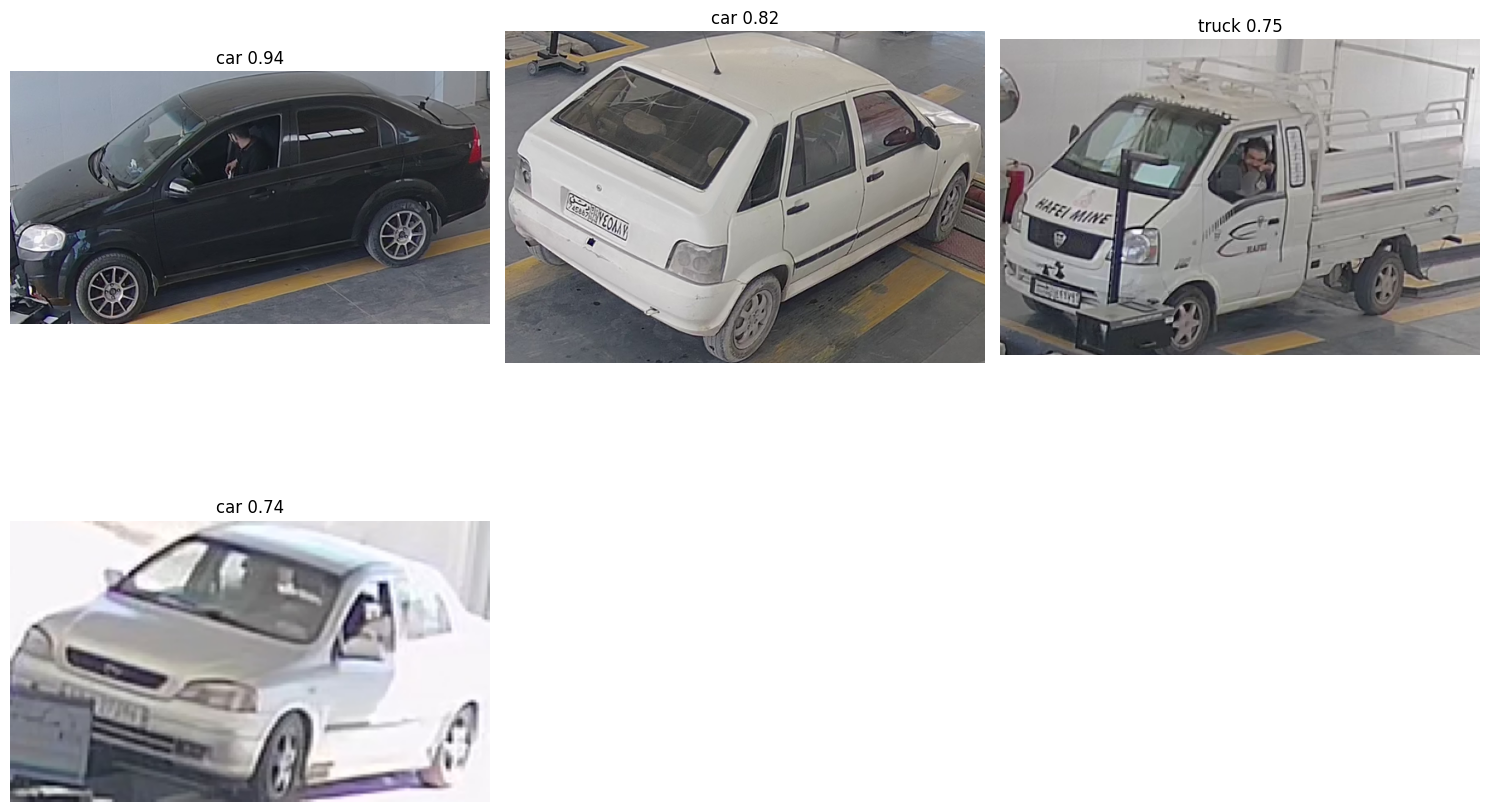

In [1]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import math
import os

# ---------------- LOAD MODEL ----------------
model = YOLO("yolov8m.pt")

# ---------------- INPUT / OUTPUT ----------------
input_folder = "input_image"
output_root = "outputs"



os.makedirs(output_root, exist_ok=True)

valid_ext = (".jpg", ".jpeg", ".png", ".bmp")

# Get list of image files
images = [
    f for f in os.listdir(input_folder)
    if f.lower().endswith(valid_ext)
]

# ---------------- CHECK EMPTY FOLDER ----------------
if len(images) == 0:
    print("📂 No images found in input folder. Please add images to 'input_image' folder.")


# ---------------- LOOP THROUGH IMAGES ----------------
for image_name in os.listdir(input_folder):

    if not image_name.lower().endswith(valid_ext):
        continue

    image_path = os.path.join(input_folder, image_name)
    img = cv2.imread(image_path)

    if img is None:
        print(f"Skipping: {image_name}")
        continue

    base_name = os.path.splitext(image_name)[0]

    base_output_dir = os.path.join(output_root, base_name)
    crops_dir = os.path.join(base_output_dir, "vehicle_crops")

    os.makedirs(crops_dir, exist_ok=True)

    cv2.imwrite(os.path.join(base_output_dir, "input_image.jpg"), img)

    # ---------------- DETECTION ----------------
    results = model(img, verbose=False)

    output_img = img.copy()
    vehicle_crops = []
    titles = []

    count = 0

    for r in results:
        for box in r.boxes:

            x1, y1, x2, y2 = map(int, box.xyxy[0])
            cls = int(box.cls[0])
            conf = float(box.conf[0])

            label = model.names[cls]

            if label in ["car", "truck", "bus"]:

                crop = img[y1:y2, x1:x2]

                if crop.size == 0:
                    continue

                # Save crop
                cv2.imwrite(
                    os.path.join(crops_dir, f"{label}_{count}.jpg"),
                    crop
                )

                # Draw detection
                cv2.rectangle(output_img, (x1, y1), (x2, y2), (0, 255, 0), 2)

                text = f"{label} {conf:.2f}"

                cv2.putText(
                    output_img,
                    text,
                    (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.7,
                    (0, 255, 0),
                    2
                )

                vehicle_crops.append(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
                titles.append(text)

                count += 1        

    # Save final output image
    cv2.imwrite(
        os.path.join(base_output_dir, "output_image.jpg"),
        output_img
    )

    # ---------------- DISPLAY IN NOTEBOOK ----------------
    output_rgb = cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB)

    print(f"\n📸 Image: {image_name} | Vehicles: {count}")

    plt.figure(figsize=(12, 6))
    plt.imshow(output_rgb)
    plt.title(f"Detections - {image_name}")
    plt.axis("off")
    plt.show()

    # ---------------- DISPLAY CROPS ----------------
    n = len(vehicle_crops)

    if n > 0:

        cols = min(3, n)
        rows = math.ceil(n / cols)

        plt.figure(figsize=(15, 5 * rows))

        for i, crop in enumerate(vehicle_crops):

            plt.subplot(rows, cols, i + 1)
            plt.imshow(crop)
            plt.title(titles[i])
            plt.axis("off")

        plt.tight_layout()
        plt.show()

    else:
        print("No vehicles detected in this image.")


Plate Crop

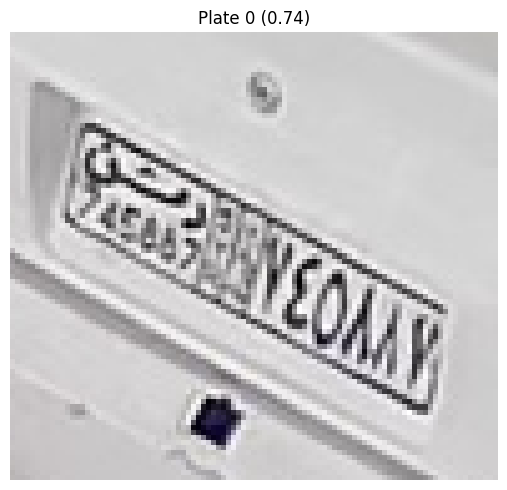

In [ ]:
from ultralytics import YOLO
import cv2
import os
import matplotlib.pyplot as plt
import math

# ---------------- LOAD MODEL ----------------
plate_model = YOLO("license_plate_detector.pt")

# ---------------- PATHS ----------------
input_root = "outputs"
output_root = "output-plate-crop"

valid_ext = (".jpg", ".jpeg", ".png", ".bmp")

os.makedirs(output_root, exist_ok=True)

# ---------------- PROCESS ----------------
for img_name in os.listdir(input_root):

    vehicle_folder = os.path.join(input_root, img_name, "vehicle_crops")

    if not os.path.exists(vehicle_folder):
        continue

    for idx, vehicle_file in enumerate(os.listdir(vehicle_folder)):

        if not vehicle_file.lower().endswith(valid_ext):
            continue

        vehicle_path = os.path.join(vehicle_folder, vehicle_file)
        vehicle_img = cv2.imread(vehicle_path)

        if vehicle_img is None:
            continue

        # ---------------- OUTPUT DIR ----------------
        base_out_dir = os.path.join(output_root, img_name, f"car_{idx}")
        os.makedirs(base_out_dir, exist_ok=True)

        cv2.imwrite(
            os.path.join(base_out_dir, "vehicle_crop.jpg"),
            vehicle_img
        )

        # ---------------- PLATE DETECTION ----------------
        results = plate_model(vehicle_img, verbose=False)

        plate_imgs = []
        plate_titles = []

        plate_count = 0

        for r in results:
            for box in r.boxes:

                x1, y1, x2, y2 = map(int, box.xyxy[0])
                conf = float(box.conf[0])

                plate_crop = vehicle_img[y1:y2, x1:x2]

                if plate_crop.size == 0:
                    continue

                # Save plate
                cv2.imwrite(
                    os.path.join(base_out_dir, f"plate_{plate_count}.jpg"),
                    plate_crop
                )

                plate_imgs.append(
                    cv2.cvtColor(plate_crop, cv2.COLOR_BGR2RGB)
                )

                plate_titles.append(f"Plate {plate_count} ({conf:.2f})")

                plate_count += 1

        # ---------------- NESTED PLOT (VEHICLE + PLATES) ----------------
        vehicle_rgb = cv2.cvtColor(vehicle_img, cv2.COLOR_BGR2RGB)

        total_rows = 1 + (math.ceil(len(plate_imgs) / 3) if plate_imgs else 0)

        plt.figure(figsize=(12, 4 * total_rows))

        # ---- Vehicle (TOP) ----
        plt.subplot(total_rows, 1, 1)
        plt.imshow(vehicle_rgb)
        plt.title(f"Vehicle: {img_name}/{vehicle_file}")
        plt.axis("off")

        # ---- Plates (BOTTOM) ----
        if len(plate_imgs) > 0:

            cols = min(3, len(plate_imgs))
            rows = math.ceil(len(plate_imgs) / cols)

            for i, img in enumerate(plate_imgs):

                plt.subplot(total_rows, cols, cols + i + 1)
                plt.imshow(img)
                plt.title(plate_titles[i])
                plt.axis("off")

        else:
            print(f"No plates detected for {vehicle_file}")

        plt.tight_layout()
        plt.show()

Use paddle venv now


📌 car/car_0
🔤 Plate: ١٢٨٢٥٢ | Conf: 0.69


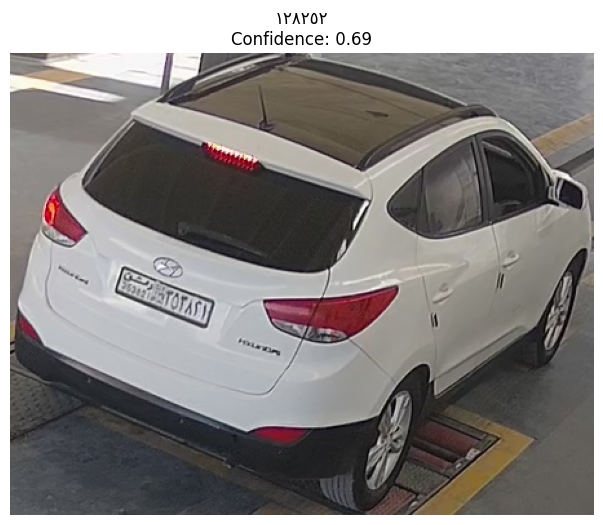


📌 car/car_1
🔤 Plate: No_Plate_Detected | Conf: 0.00


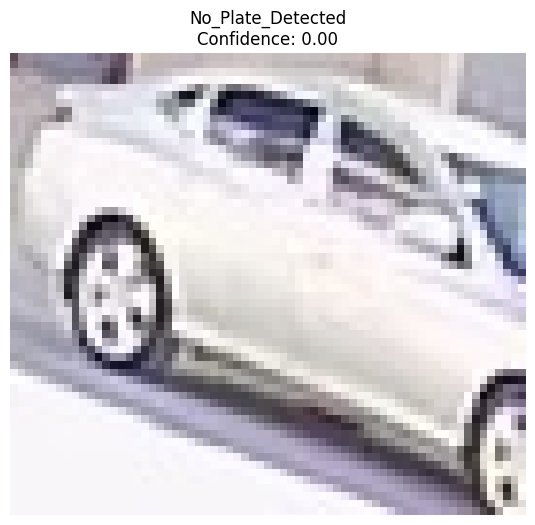


📌 car2/car_0
🔤 Plate: No_Plate_Detected | Conf: 0.00


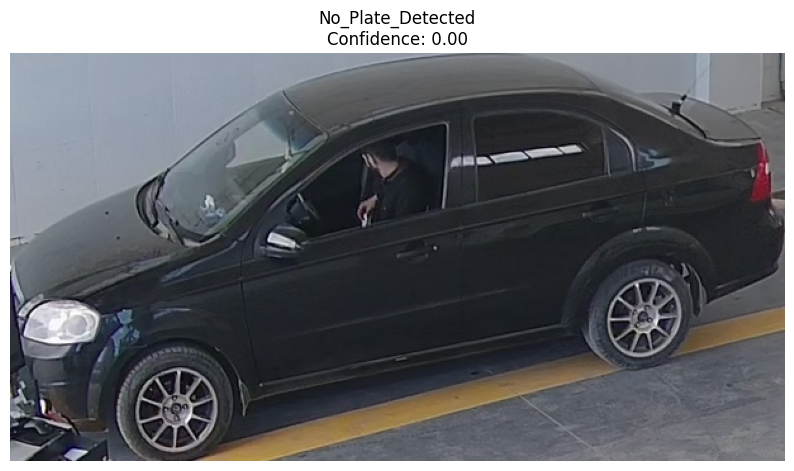


📌 car2/car_1
🔤 Plate: ٧٨٨٥٤٧ | Conf: 0.90


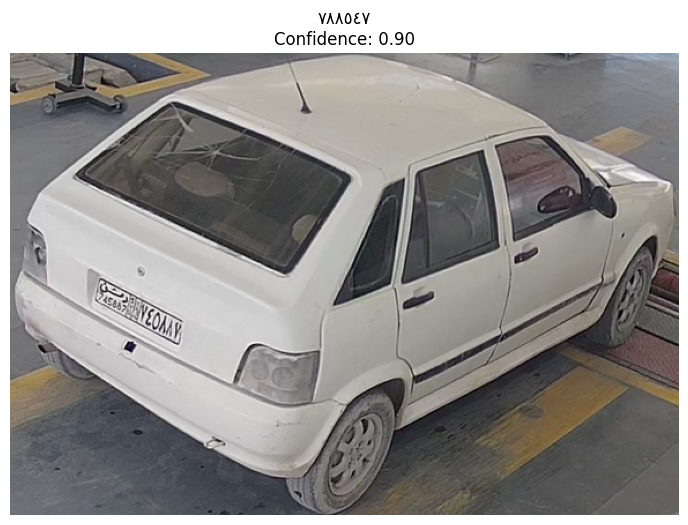


📌 car2/car_2
🔤 Plate: No_Plate_Detected | Conf: 0.00


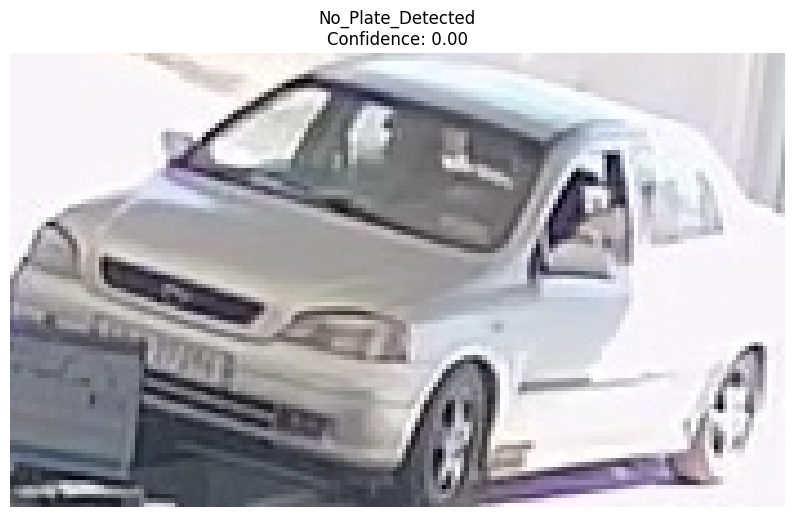


📌 car2/car_3
🔤 Plate: HF NE | Conf: 0.73


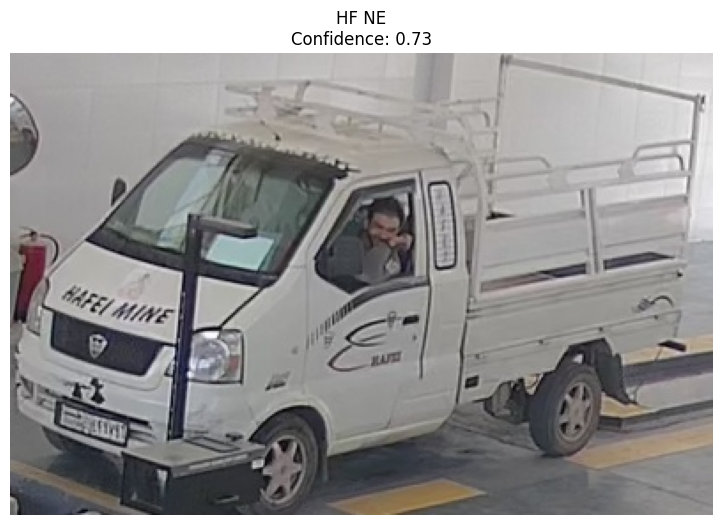

In [2]:
import os
import cv2
import matplotlib.pyplot as plt

# Fix Paddle MKLDNN issues (Windows)
os.environ["FLAGS_use_mkldnn"] = "0"

from paddleocr import PaddleOCR

# ---------------- INIT OCR ----------------
ocr = PaddleOCR(
    use_angle_cls=True,
    lang='ar',   # change to 'en' if needed
    show_log=False
)

# ---------------- PATHS ----------------
input_root = "output-plate-crop"
output_root = "output-plate-detection"

os.makedirs(output_root, exist_ok=True)

valid_ext = (".jpg", ".jpeg", ".png", ".bmp")

# ---------------- PROCESS ALL IMAGES ----------------
for img_name in os.listdir(input_root):

    img_folder = os.path.join(input_root, img_name)

    if not os.path.isdir(img_folder):
        continue

    for car_name in os.listdir(img_folder):

        car_folder = os.path.join(img_folder, car_name)

        if not os.path.isdir(car_folder):
            continue

        # Look for car image inside folder
        car_image_path = None

        for f in os.listdir(car_folder):
            if f.lower().endswith(valid_ext) and "vehicle" in f.lower() or "car" in f.lower():
                car_image_path = os.path.join(car_folder, f)
                break

        # fallback: take first image if naming differs
        if car_image_path is None:
            for f in os.listdir(car_folder):
                if f.lower().endswith(valid_ext):
                    car_image_path = os.path.join(car_folder, f)
                    break

        if car_image_path is None:
            print(f"⚠ No image found in {car_folder}")
            continue

        img = cv2.imread(car_image_path)

        if img is None:
            print(f"⚠ Cannot read {car_image_path}")
            continue

        # ---------------- OCR ----------------
        result = ocr.ocr(img)

        plate_texts = []
        confidences = []

        if result and result[0]:

            for line in result[0]:

                if line is None or len(line) < 2:
                    continue

                text = line[1][0] if line[1] else ""
                conf = line[1][1] if line[1] else 0

                if text:
                    plate_texts.append(text)
                    confidences.append(conf)

            plate_text = " ".join(plate_texts).strip()

            if len(confidences) > 0:
                avg_conf = sum(confidences) / len(confidences)
            else:
                avg_conf = 0

        else:
            plate_text = "No_Plate_Detected"
            avg_conf = 0

        # ---------------- SAFE FILE NAME ----------------
        safe_text = plate_text.replace(" ", "_").replace("/", "_")

        # ---------------- OUTPUT DIR ----------------
        out_dir = os.path.join(output_root, img_name, car_name)
        os.makedirs(out_dir, exist_ok=True)

        # Save image
        cv2.imwrite(os.path.join(out_dir, "car_image.jpg"), img)

        # Save plate text as filename (requested)
        text_file_path = os.path.join(out_dir, f"{safe_text}.txt")
        with open(text_file_path, "w", encoding="utf-8") as f:
            f.write(f"Plate Text: {plate_text}\n")
            f.write(f"Confidence: {avg_conf:.2f}\n")

        # ---------------- DISPLAY ----------------
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        print(f"\n📌 {img_name}/{car_name}")
        print(f"🔤 Plate: {plate_text} | Conf: {avg_conf:.2f}")

        plt.figure(figsize=(10, 6))
        plt.imshow(img_rgb)
        plt.title(f"{plate_text}\nConfidence: {avg_conf:.2f}")
        plt.axis("off")
        plt.show()

In [ ]:
import re

def clean_plate(text):
    text = text.upper()
    text = re.sub(r'[^A-Z0-9\u0600-\u06FF ]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

plate_text = clean_plate(plate_text)

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

plate_dir = "plate_crops"

results = []

for name in os.listdir(plate_dir):
    path = os.path.join(plate_dir, name)

    if not os.path.isfile(path):
        continue

    img = cv2.imread(path)

    if img is None:
        results.append((name, "Failed to read", 0))
        continue

    result = ocr.ocr(img, cls=True)

    if not result or result[0] is None or len(result[0]) == 0:
        results.append((name, "No text", 0))
        continue

    text_parts = []
    confs = []

    for line in result[0]:
        if line and len(line) > 1:
            text_parts.append(line[1][0])
            confs.append(line[1][1])

    text = clean_plate(" ".join(text_parts))
    avg_conf = sum(confs) / len(confs) if confs else 0

    results.append((name, text, avg_conf))

# ---- Plot ----
n = len(results)
cols = 3
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten()

for ax in axes[n:]:
    ax.axis("off")

for idx, (name, text, conf) in enumerate(results):
    path = os.path.join(plate_dir, name)

    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    axes[idx].imshow(img)
    axes[idx].set_title(
        f"{text}\nConf: {conf:.2f}",
        fontsize=10
    )
    axes[idx].axis("off")

plt.tight_layout()
plt.show()